# Train YOLO26 - Nhận dạng biển số xe Việt Nam


In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: c:\alpr\alpr-yolo26


## 1. Cài thư viện & kiểm tra GPU

In [ ]:

import torch
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

CUDA: True NVIDIA GeForce GTX 1650


## 2a. Tải dataset từ Roboflow
Bỏ qua nếu đã có `data/biensoxe`. Nếu version lỗi, đổi `ROBOFLOW_VERSION` trong `src/config.py`.

In [3]:
import os, getpass
from src.config import DATASET_DIR
if not (DATASET_DIR / "train").exists():
    if not os.environ.get("ROBOFLOW_API_KEY"):
        os.environ["ROBOFLOW_API_KEY"] = getpass.getpass("Roboflow API key: ")
    from src.data.download import download
    download()
else:
    print("Dataset da co:", DATASET_DIR)

Dataset da co: C:\alpr\alpr-yolo26\data\biensoxe


## 2b. Kiểm tra & sửa dataset
Phát hiện label sai định dạng (polygon lẫn vào detection) và chuyển thành bbox. File gốc được backup trong `_label_backup/`.

In [4]:
from src.data.dataset import scan_labels, fix_labels, make_data_yaml
r = scan_labels()
print(f"Label files: {r['files']} | Bad: {len(r['bad'])} | Empty: {len(r['empty'])}")
if r["bad"]:
    print(fix_labels())
    r = scan_labels(); print("Sau khi sua -> Bad:", len(r["bad"]))
print("data yaml:", make_data_yaml())

Label files: 1262 | Bad: 0 | Empty: 0
data yaml: C:\alpr\alpr-yolo26\data\biensoxe\data.resolved.yaml


## 3. Xem nhanh dữ liệu train

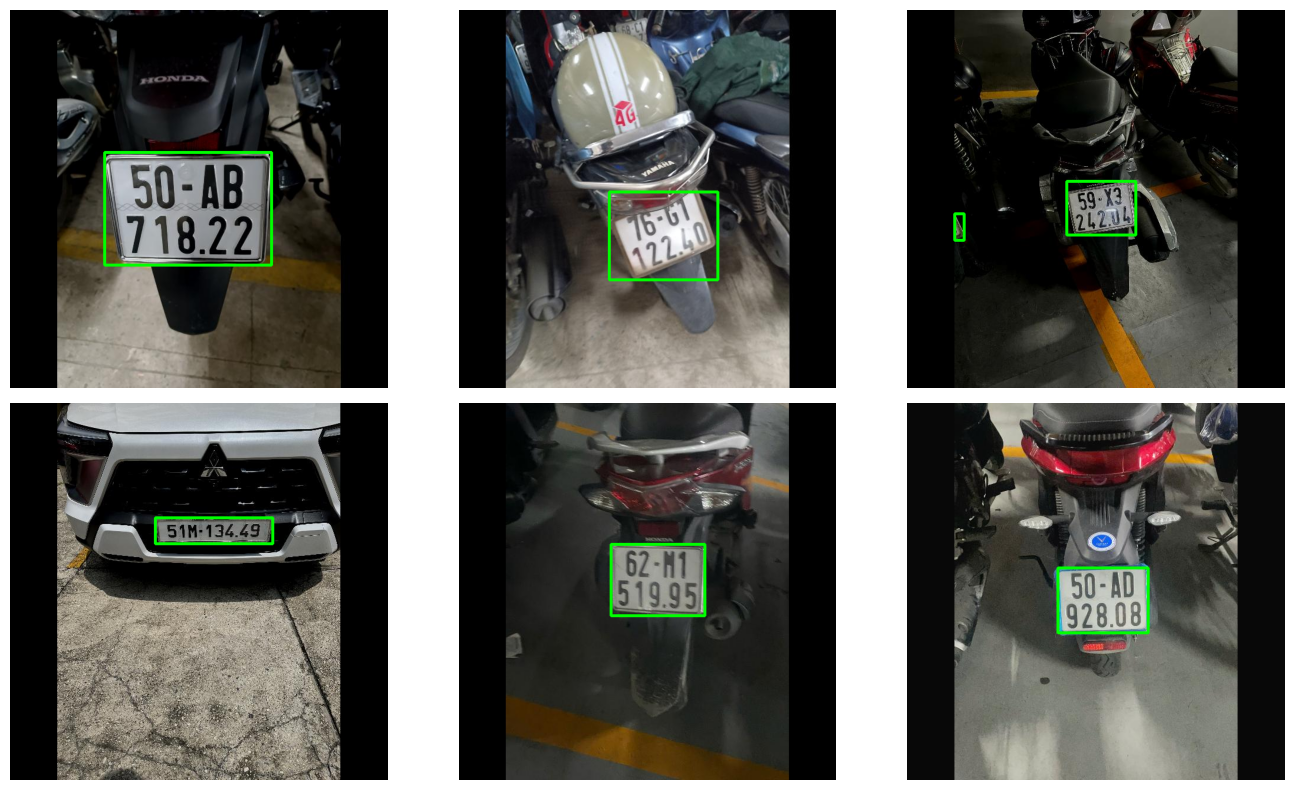

In [5]:
import cv2, random, matplotlib.pyplot as plt
from src.config import DATASET_DIR
imgs = sorted((DATASET_DIR/"train"/"images").glob("*.*")); random.seed(0)
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
for ax, p in zip(axs.ravel(), random.sample(imgs, 6)):
    im = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB); h, w = im.shape[:2]
    lb = DATASET_DIR/"train"/"labels"/(p.stem+".txt")
    for line in lb.read_text().splitlines():
        _, cx, cy, bw, bh = map(float, line.split()[:5])
        cv2.rectangle(im, (int((cx-bw/2)*w), int((cy-bh/2)*h)), (int((cx+bw/2)*w), int((cy+bh/2)*h)), (0,255,0), 3)
    ax.imshow(im); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Train
Trên Windows dùng `workers=0` để tránh lỗi DataLoader.

In [6]:
from src.training.train import train
best = train(
    epochs=100, imgsz=640, batch=16, patience=30,
    workers=0 if os.name == "nt" else 4,
    name="yolo26n_plates",
)
best

Ultralytics 8.4.174  Python-3.11.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\alpr\alpr-yolo26\data\biensoxe\data.resolved.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\alpr\alpr-yolo26\yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo2

WindowsPath('C:/alpr/alpr-yolo26/models/best.pt')

## 5. Kiểm tra biểu đồ huấn luyện

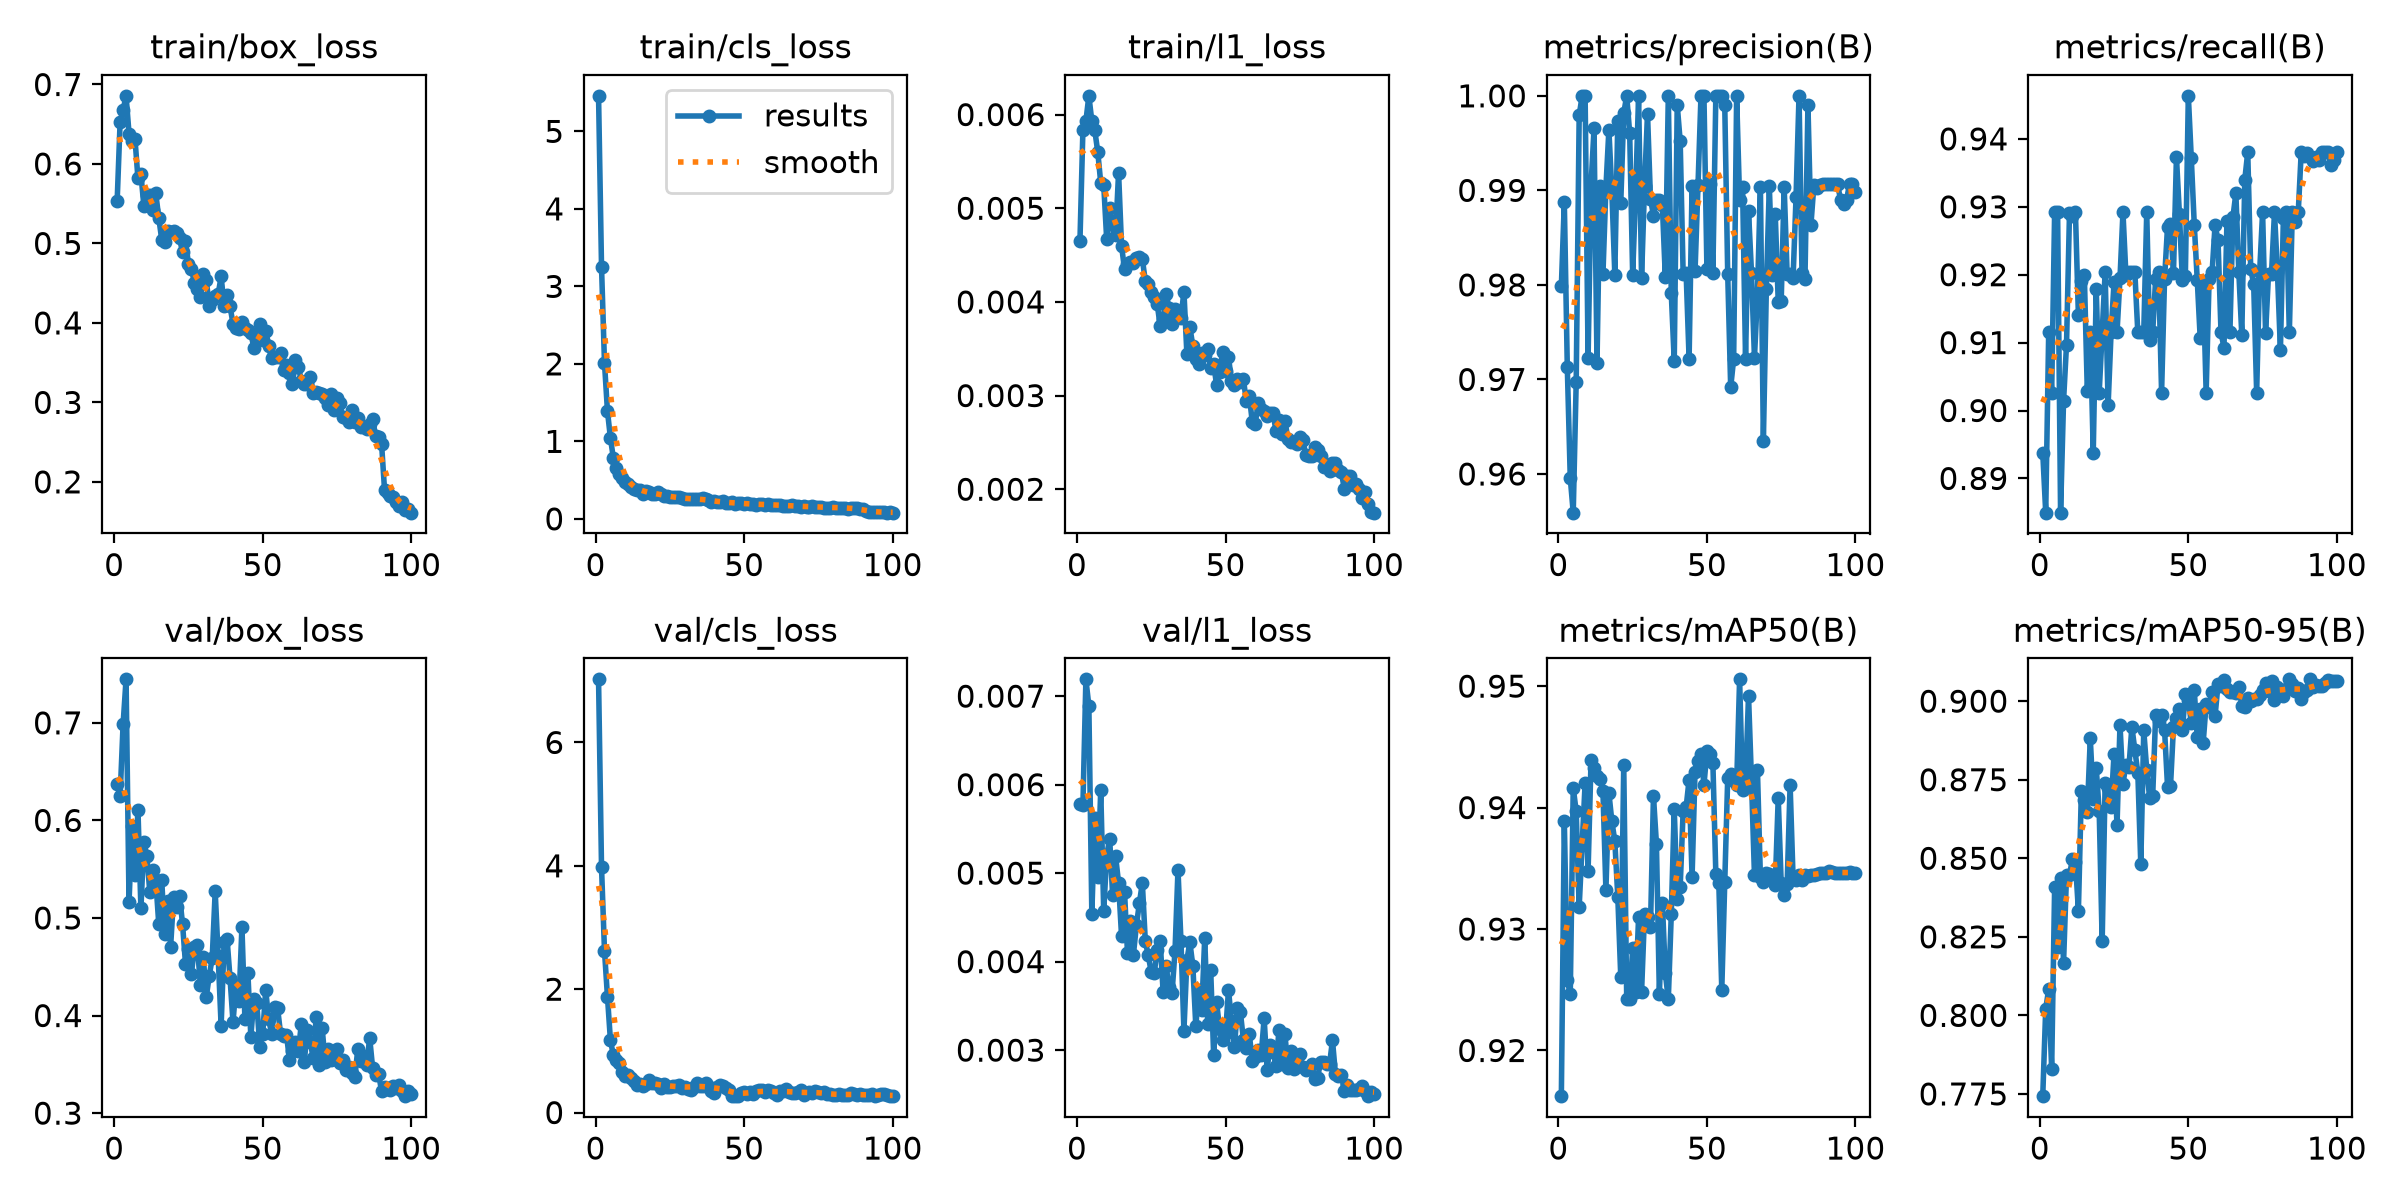

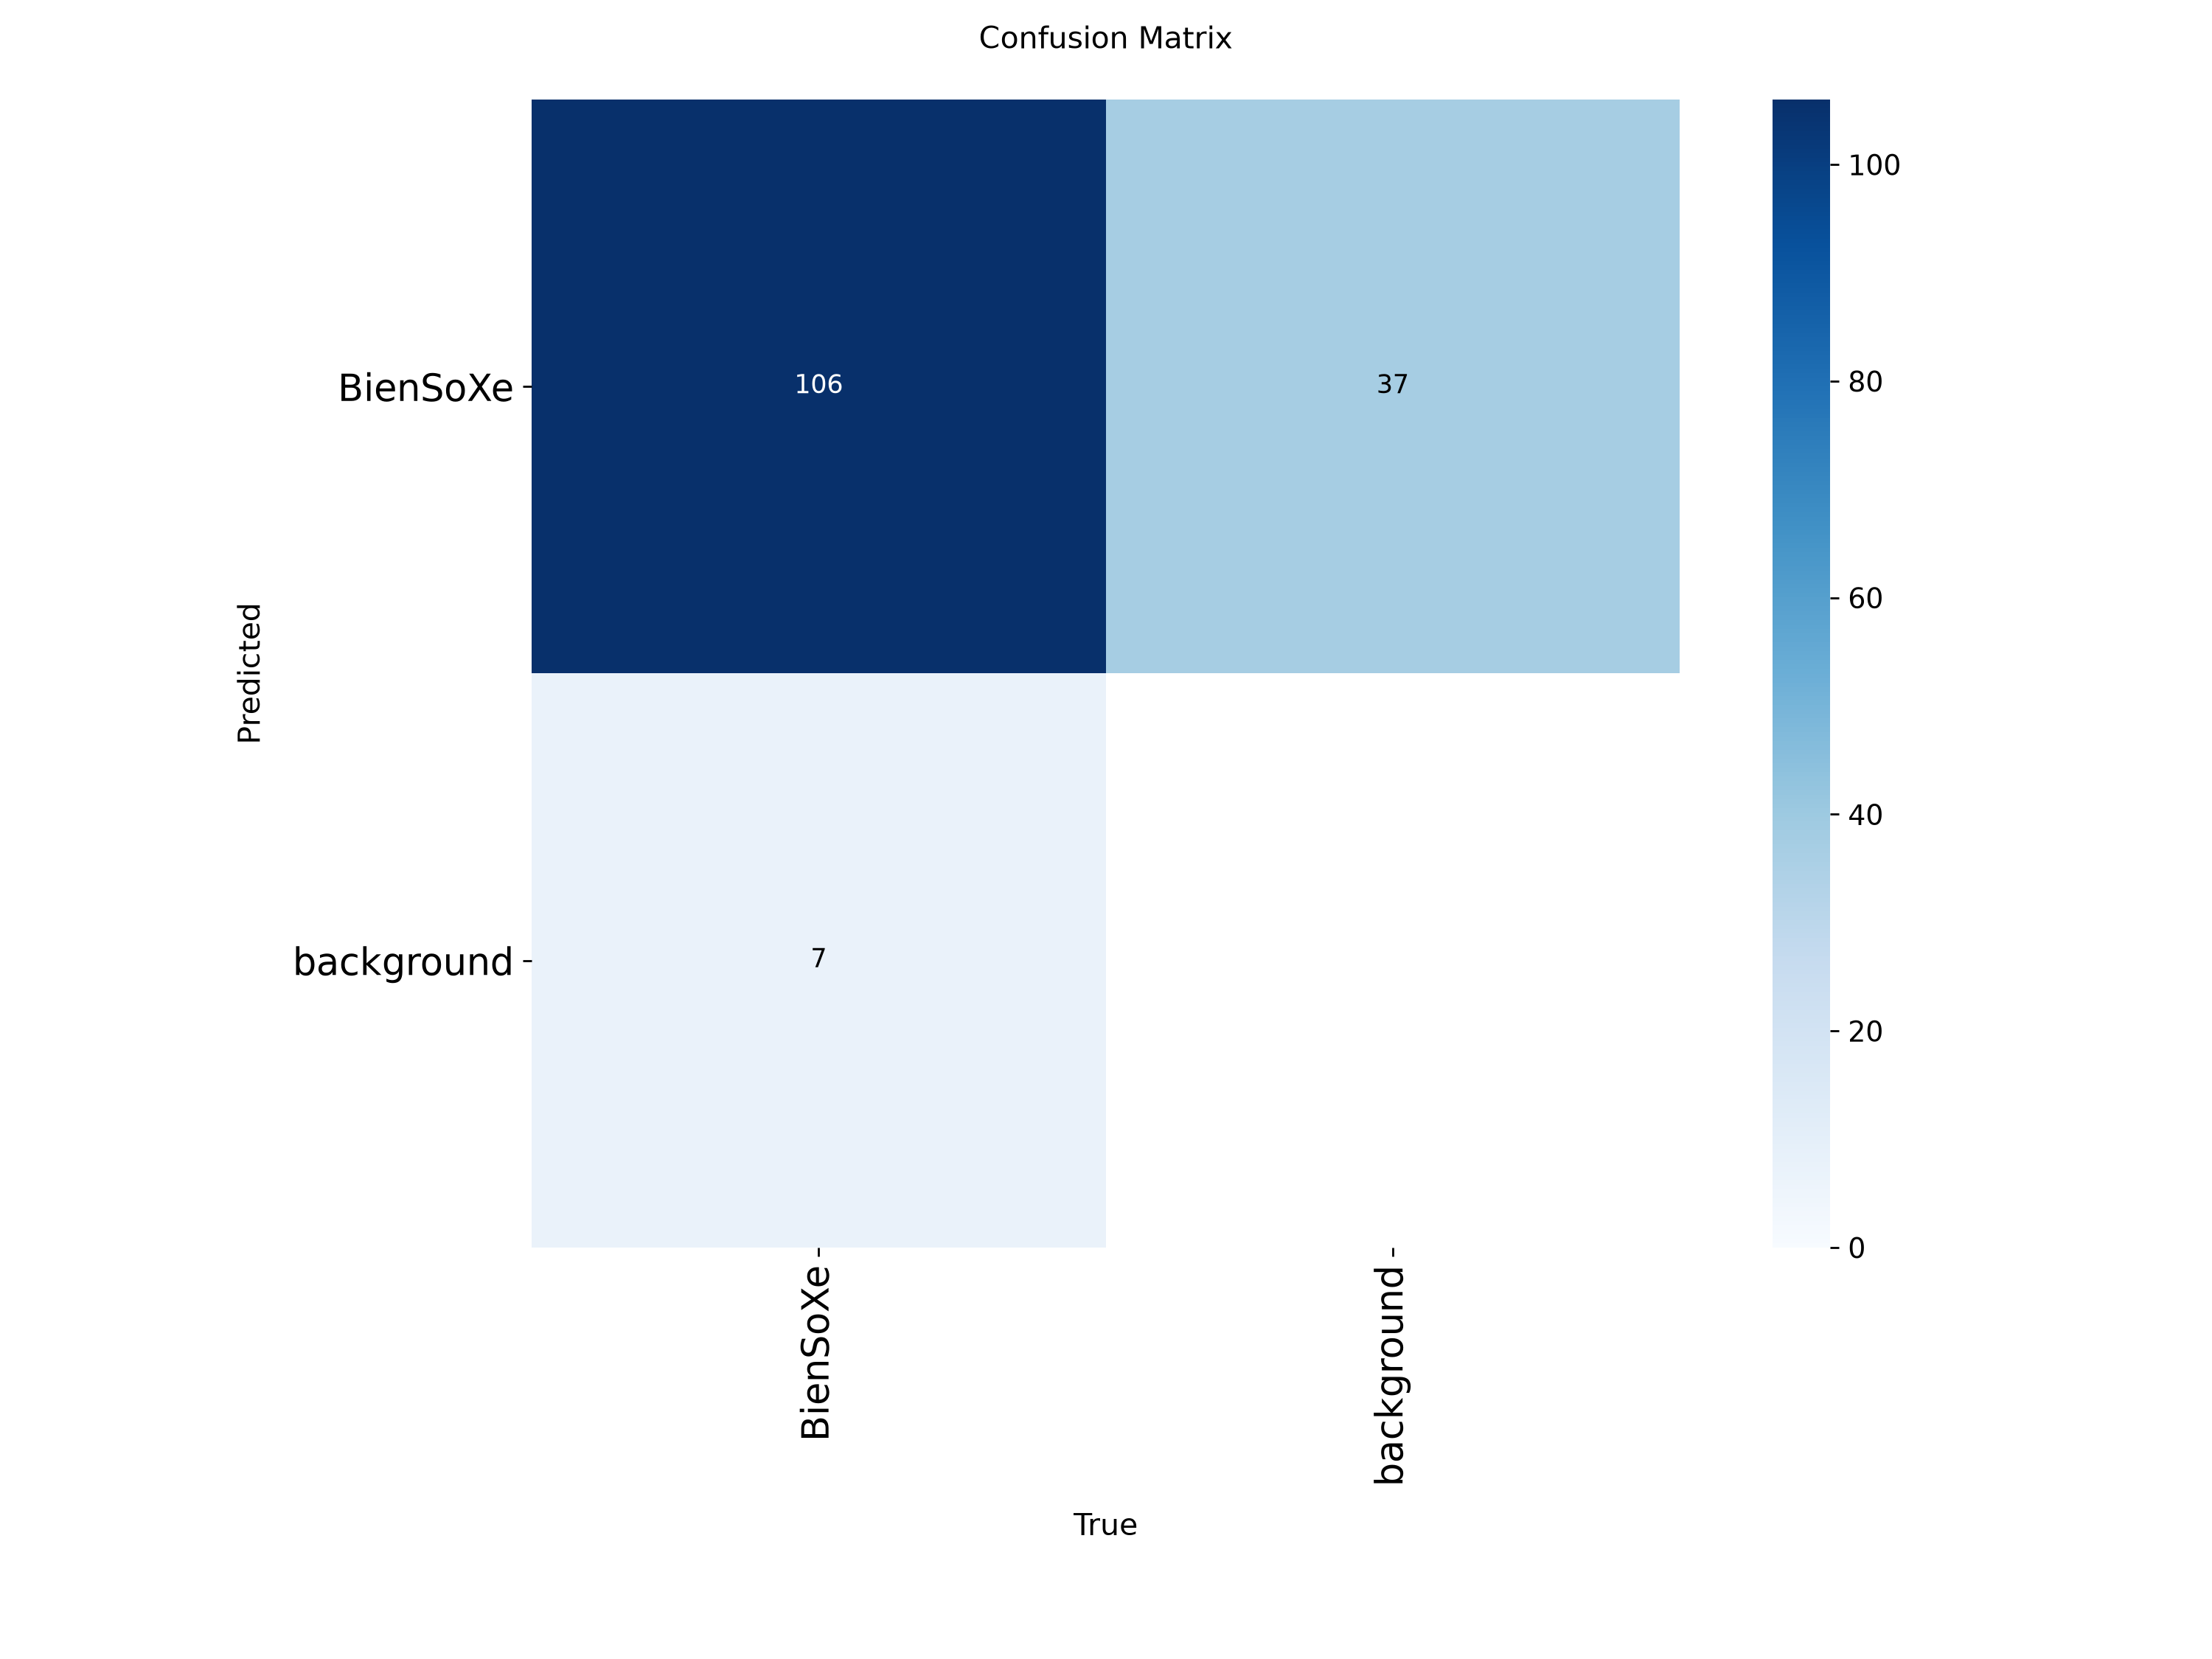

In [7]:
from IPython.display import Image, display
from src.config import EXPERIMENTS_DIR
for f in ["results.png", "confusion_matrix.png", "PR_curve.png"]:
    p = EXPERIMENTS_DIR/"yolo26n_plates"/f
    if p.exists(): display(Image(str(p), width=800))

## 6. Đánh giá trên valid / test

In [8]:
from src.evaluation.evaluate import evaluate
m_val = evaluate(split="valid")
m_test = evaluate(split="test")

Ultralytics 8.4.174  Python-3.11.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 536.0162.3 MB/s, size: 76.0 KB)
val: Scanning C:\alpr\alpr-yolo26\data\biensoxe\valid\labels.cache... 105 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.9s/it 20.1s0.5ss
                   all        105        113      0.991      0.937      0.935      0.907
Speed: 15.4ms preprocess, 12.2ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to C:\alpr\alpr-yolo26\experiments\eval_valid
{
  "split": "valid",
  "mode": "end2end (NMS-free)",
  "precision": 0.9906469081403595,
  "recall": 0.9373206383005045,
  "f1": 0.9632462890599017,
  "mAP50": 0.9348130841121496,
  "mAP50-95": 0.9069517803637211
}
Ultralytics 8.4.174  Py

## 7. Kiểm thử Pipeline (Preprocessing → Detection → PaddleOCR)

Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dangn\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


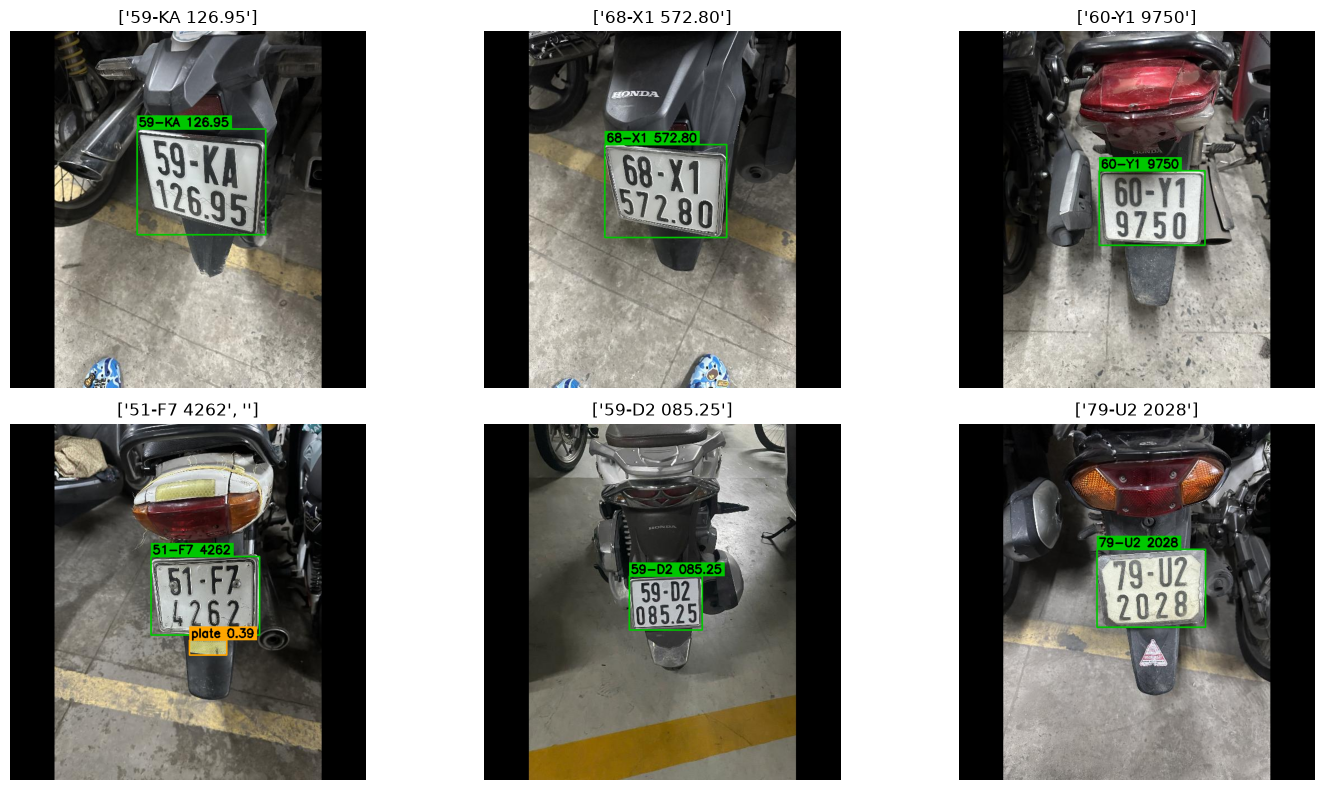

In [16]:
from src.inference.pipeline import ALPRPipeline
pipe = ALPRPipeline()
test_imgs = sorted((DATASET_DIR/"test"/"images").glob("*.*"))[7:13]
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
for ax, p in zip(axs.ravel(), test_imgs):
    img = cv2.imread(str(p)); res = pipe.run(img)
    ax.imshow(cv2.cvtColor(pipe.annotate(img, res), cv2.COLOR_BGR2RGB)); ax.axis("off")
    ax.set_title(str([r.get("plate_formatted") for r in res]))
plt.tight_layout(); plt.show()

## 8. Ngưỡng conf / NMS, độ trễ và FPS
Lần đầu chạy OCR, PaddleOCR sẽ tải model (cần Internet).

In [10]:
from src.evaluation.sweep import sweep
sweep(split='test')

WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is deprecated and will be removed in the future. Use 'nms=None' instead.
WARNING 'end2end=False' is dep

[{'mode': 'end2end (NMS-free)',
  'conf': 0.05,
  'precision': 0.9464,
  'recall': 0.9815,
  'f1': 0.9636,
  'tp': 53,
  'fp': 3,
  'fn': 1},
 {'mode': 'end2end (NMS-free)',
  'conf': 0.1,
  'precision': 0.9464,
  'recall': 0.9815,
  'f1': 0.9636,
  'tp': 53,
  'fp': 3,
  'fn': 1},
 {'mode': 'end2end (NMS-free)',
  'conf': 0.2,
  'precision': 0.9636,
  'recall': 0.9815,
  'f1': 0.9725,
  'tp': 53,
  'fp': 2,
  'fn': 1},
 {'mode': 'end2end (NMS-free)',
  'conf': 0.25,
  'precision': 0.9636,
  'recall': 0.9815,
  'f1': 0.9725,
  'tp': 53,
  'fp': 2,
  'fn': 1},
 {'mode': 'end2end (NMS-free)',
  'conf': 0.3,
  'precision': 0.9636,
  'recall': 0.9815,
  'f1': 0.9725,
  'tp': 53,
  'fp': 2,
  'fn': 1},
 {'mode': 'end2end (NMS-free)',
  'conf': 0.4,
  'precision': 0.9815,
  'recall': 0.9815,
  'f1': 0.9815,
  'tp': 53,
  'fp': 1,
  'fn': 1},
 {'mode': 'end2end (NMS-free)',
  'conf': 0.5,
  'precision': 0.9815,
  'recall': 0.9815,
  'f1': 0.9815,
  'tp': 53,
  'fp': 1,
  'fn': 1},
 {'mode': '

In [11]:
from src.evaluation.benchmark import benchmark
benchmark(n=50)
benchmark(n=50, full=True)

Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dangn\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


{
  "mode": "detector (preprocess+detect)",
  "device": "NVIDIA GeForce GTX 1650",
  "images": 50,
  "warmup": 5,
  "end2end": true,
  "stages": {
    "preprocess": {
      "mean_ms": 0.01,
      "p50_ms": 0.01,
      "p95_ms": 0.01
    },
    "detect": {
      "mean_ms": 27.55,
      "p50_ms": 20.33,
      "p95_ms": 78.9
    },
    "total": {
      "mean_ms": 27.56,
      "p50_ms": 20.34,
      "p95_ms": 78.95
    }
  },
  "fps": 36.3,
  "measured_at": "2026-10-08 20:19:47"
}
{
  "mode": "full (preprocess+detect+OCR)",
  "device": "NVIDIA GeForce GTX 1650",
  "images": 50,
  "warmup": 5,
  "end2end": true,
  "stages": {
    "preprocess": {
      "mean_ms": 0.0,
      "p50_ms": 0.0,
      "p95_ms": 0.01
    },
    "detect": {
      "mean_ms": 43.59,
      "p50_ms": 41.72,
      "p95_ms": 47.56
    },
    "ocr": {
      "mean_ms": 95.89,
      "p50_ms": 92.06,
      "p95_ms": 105.53
    },
    "total": {
      "mean_ms": 139.49,
      "p50_ms": 135.81,
      "p95_ms": 183.74
    }
  },


{'mode': 'full (preprocess+detect+OCR)',
 'device': 'NVIDIA GeForce GTX 1650',
 'images': 50,
 'warmup': 5,
 'end2end': True,
 'stages': {'preprocess': {'mean_ms': 0.0, 'p50_ms': 0.0, 'p95_ms': 0.01},
  'detect': {'mean_ms': 43.59, 'p50_ms': 41.72, 'p95_ms': 47.56},
  'ocr': {'mean_ms': 95.89, 'p50_ms': 92.06, 'p95_ms': 105.53},
  'total': {'mean_ms': 139.49, 'p50_ms': 135.81, 'p95_ms': 183.74}},
 'fps': 7.2,
 'measured_at': '2026-10-08 20:19:56'}